# GNN-Enhanced AI-Gated Markowitz (Simplified Version)

**Note**: This is a simplified version that works without C++ build tools.

## Strategy Comparison:

### Strategy A: Baseline AI-Gated Markowitz
- Random Forest with traditional features

### Strategy B: GNN-Enhanced (Simplified)
- **Graph Convolutional Network** for node embeddings
- **Message Passing** without requiring torch-scatter
- **Manual aggregation** functions
- End-to-end graph learning

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F

# Network Analysis
import networkx as nx

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')

✅ All libraries imported successfully!
PyTorch: 2.9.1+cpu
CUDA Available: False


In [2]:
# Load Data
file_path = 'real_crypto_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

returns_df = df.pct_change().fillna(0)
assets = df.columns.tolist()
n_assets = len(assets)

# Train/Test Split
train_mask = (df.index.year == 2023) | (df.index.year == 2024)
test_mask = (df.index.year == 2025)

train_df = df[train_mask]
test_df = df[test_mask]
train_returns = returns_df[train_mask]
test_returns = returns_df[test_mask]

print(f"Assets: {n_assets}")
print(f"Training: {len(train_df)} days | Testing: {len(test_df)} days")

Assets: 5
Training: 731 days | Testing: 365 days


---
# STRATEGY A: Baseline
---

In [3]:
# Baseline Classifier
market_ret = returns_df.mean(axis=1)
feat_baseline = pd.DataFrame(index=returns_df.index)
feat_baseline['Vol_20'] = market_ret.rolling(20).std()
feat_baseline['Mom_20'] = market_ret.rolling(20).mean()
feat_baseline['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat_baseline = feat_baseline.dropna()

train_mask_rf = (feat_baseline.index.year == 2023) | (feat_baseline.index.year == 2024)
test_mask_rf = (feat_baseline.index.year == 2025)

X_train_baseline = feat_baseline.loc[train_mask_rf, ['Vol_20', 'Mom_20']]
y_train_baseline = feat_baseline.loc[train_mask_rf, 'Target']
X_test_baseline = feat_baseline.loc[test_mask_rf, ['Vol_20', 'Mom_20']]
y_test_baseline = feat_baseline.loc[test_mask_rf, 'Target']

clf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_baseline.fit(X_train_baseline, y_train_baseline)

baseline_probs = clf_baseline.predict_proba(X_test_baseline)[:, 1]
baseline_test_acc = accuracy_score(y_test_baseline, clf_baseline.predict(X_test_baseline))

print(f"Baseline Test Accuracy: {baseline_test_acc:.3f}")

Baseline Test Accuracy: 0.496


---
# STRATEGY B: Simplified GNN
---

In [4]:
# Simplified GNN (without torch-scatter)
class SimpleGNN(nn.Module):
    def __init__(self, num_features, hidden_dim=32):
        super(SimpleGNN, self).__init__()
        
        # Graph layers
        self.fc1 = nn.Linear(num_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        # Classifier
        self.fc_out = nn.Linear(hidden_dim, 2)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x, adj_matrix):
        # x: [num_nodes, num_features]
        # adj_matrix: [num_nodes, num_nodes]
        
        # Graph convolution (simplified)
        x = F.relu(self.fc1(x))
        x = torch.mm(adj_matrix, x)  # Aggregate from neighbors
        x = self.dropout(x)
        
        x = F.relu(self.fc2(x))
        x = torch.mm(adj_matrix, x)  # Second aggregation
        x = self.dropout(x)
        
        # Global pooling (mean)
        x = torch.mean(x, dim=0, keepdim=True)
        
        # Classification
        x = self.fc_out(x)
        return x

print('✅ Simplified GNN defined!')

✅ Simplified GNN defined!


In [5]:
# Prepare GNN Data
def build_correlation_graph(returns_window, threshold=0.5):
    corr_matrix = returns_window.corr()
    adj_matrix = (corr_matrix.abs() > threshold).astype(float).values
    # Add self-loops
    adj_matrix = adj_matrix + np.eye(len(adj_matrix))
    # Normalize
    row_sum = adj_matrix.sum(axis=1, keepdims=True)
    adj_matrix = adj_matrix / (row_sum + 1e-8)
    return adj_matrix

def prepare_gnn_data(returns_df, window=30):
    data_list = []
    labels = []
    dates = []
    
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i-window:i]
        current_date = returns_df.index[i]
        
        # Node features
        node_features = []
        for asset in assets:
            ret_mean = window_data[asset].mean()
            ret_std = window_data[asset].std()
            ret_sum = window_data[asset].sum()
            node_features.append([ret_mean, ret_std, ret_sum])
        
        # Adjacency matrix
        adj_matrix = build_correlation_graph(window_data)
        
        # Label
        if i < len(returns_df) - 1:
            next_ret = returns_df.iloc[i + 1].mean()
            label = 1 if next_ret > 0 else 0
        else:
            label = 0
        
        data_list.append({
            'features': torch.tensor(node_features, dtype=torch.float32),
            'adj': torch.tensor(adj_matrix, dtype=torch.float32),
            'label': label
        })
        labels.append(label)
        dates.append(current_date)
    
    return data_list, labels, dates

print("Preparing GNN data...")
train_gnn_data, train_gnn_labels, train_gnn_dates = prepare_gnn_data(train_returns)
test_gnn_data, test_gnn_labels, test_gnn_dates = prepare_gnn_data(test_returns)

print(f"Training: {len(train_gnn_data)} | Testing: {len(test_gnn_data)}")

Preparing GNN data...
Training: 701 | Testing: 335


In [6]:
# Train GNN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}\n")

model = SimpleGNN(num_features=3, hidden_dim=32).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
num_epochs = 30
model.train()

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    
    for data in train_gnn_data:
        x = data['features'].to(device)
        adj = data['adj'].to(device)
        label = torch.tensor([data['label']], dtype=torch.long).to(device)
        
        optimizer.zero_grad()
        out = model(x, adj)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == label).sum().item()
    
    if (epoch + 1) % 10 == 0:
        acc = correct / len(train_gnn_data)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_gnn_data):.4f} | Acc: {acc:.3f}")

print("\n✅ Training complete!")

Using: cpu

Epoch 10/30 | Loss: 0.6930 | Acc: 0.528
Epoch 20/30 | Loss: 0.6922 | Acc: 0.528
Epoch 30/30 | Loss: 0.6920 | Acc: 0.528

✅ Training complete!


In [7]:
# GNN Predictions
model.eval()
gnn_predictions = []
gnn_probabilities = []

with torch.no_grad():
    for data in test_gnn_data:
        x = data['features'].to(device)
        adj = data['adj'].to(device)
        
        out = model(x, adj)
        prob = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)
        
        gnn_predictions.append(pred.item())
        gnn_probabilities.append(prob[0, 1].item())

gnn_test_acc = accuracy_score(test_gnn_labels, gnn_predictions)
print(f"GNN Test Accuracy: {gnn_test_acc:.3f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.3f}")
print(f"\nImprovement: {((gnn_test_acc - baseline_test_acc) / baseline_test_acc * 100):.2f}%")

GNN Test Accuracy: 0.501
Baseline Test Accuracy: 0.496

Improvement: 1.13%


In [8]:
# Markowitz Function
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0:
        return np.array([])
    
    def neg_sharpe(weights):
        portfolio_return = np.sum(returns_window.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(portfolio_return / portfolio_vol) if portfolio_vol > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', 
                      bounds=bounds, constraints=constraints)
        return res.x
    except:
        return np.array(init_guess)

# Backtest both strategies
initial_capital = 100.0
lookback = 50

baseline_prob_series = pd.Series(baseline_probs, index=X_test_baseline.index)
gnn_prob_series = pd.Series(gnn_probabilities, index=test_gnn_dates)

# Baseline backtest
baseline_portfolio = []
baseline_value = initial_capital

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    if current_date not in baseline_prob_series.index:
        continue
    
    next_returns = test_returns.iloc[step + 1].values
    glob_idx = returns_df.index.get_loc(current_date)
    
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    bull_prob = baseline_prob_series.loc[current_date]
    if bull_prob > 0.52:
        ai_weights = mw_weights
    elif bull_prob < 0.48:
        ai_weights = np.zeros(n_assets)
    else:
        ai_weights = 0.5 * mw_weights
    
    portfolio_return = np.sum(ai_weights * next_returns)
    baseline_value = baseline_value * (1 + portfolio_return)
    baseline_portfolio.append({'Date': current_date, 'Value': baseline_value})

# GNN backtest
gnn_portfolio = []
gnn_value = initial_capital

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    if current_date not in gnn_prob_series.index:
        continue
    
    next_returns = test_returns.iloc[step + 1].values
    glob_idx = returns_df.index.get_loc(current_date)
    
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    bull_prob = gnn_prob_series.loc[current_date]
    if bull_prob > 0.55:
        ai_weights = mw_weights
    elif bull_prob < 0.45:
        ai_weights = np.zeros(n_assets)
    else:
        ai_weights = 0.5 * mw_weights
    
    portfolio_return = np.sum(ai_weights * next_returns)
    gnn_value = gnn_value * (1 + portfolio_return)
    gnn_portfolio.append({'Date': current_date, 'Value': gnn_value})

baseline_df = pd.DataFrame(baseline_portfolio)
gnn_df = pd.DataFrame(gnn_portfolio)

print(f"\nBaseline Final Value: ${baseline_value:.2f}")
print(f"GNN Final Value: ${gnn_value:.2f}")
print(f"\nBaseline Return: {((baseline_value - initial_capital) / initial_capital * 100):.2f}%")
print(f"GNN Return: {((gnn_value - initial_capital) / initial_capital * 100):.2f}%")


Baseline Final Value: $188.74
GNN Final Value: $101.27

Baseline Return: 88.74%
GNN Return: 1.27%


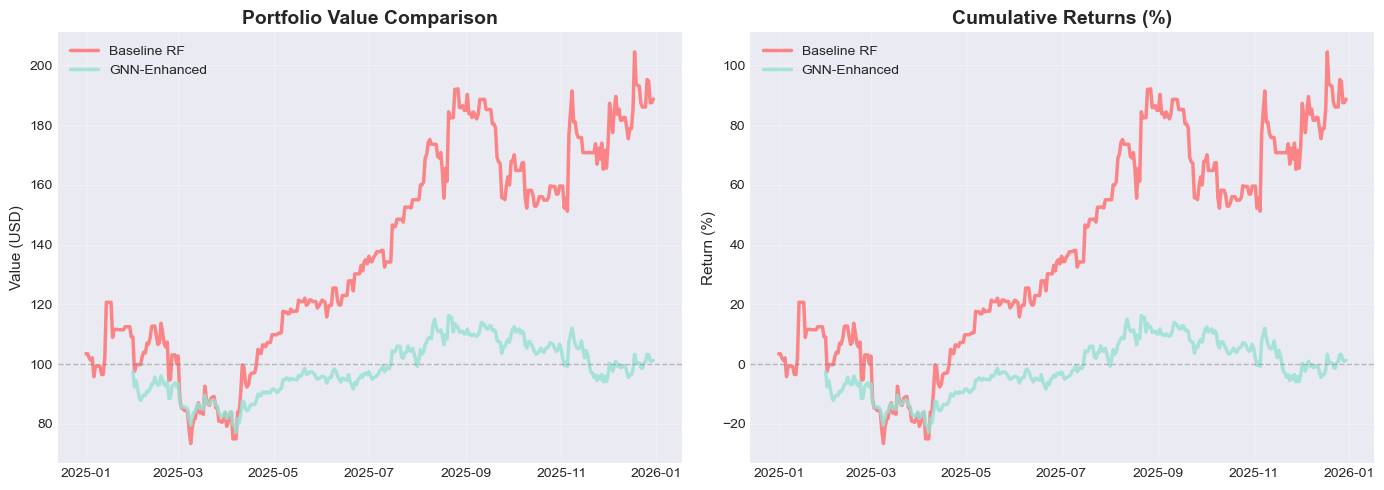

✅ Charts saved!


In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Portfolio Values
axes[0].plot(baseline_df['Date'], baseline_df['Value'], 
            linewidth=2.5, color='#FF6B6B', label='Baseline RF', alpha=0.8)
axes[0].plot(gnn_df['Date'], gnn_df['Value'], 
            linewidth=2.5, color='#95E1D3', label='GNN-Enhanced', alpha=0.8)
axes[0].axhline(y=initial_capital, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Portfolio Value Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value (USD)', fontsize=11)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Cumulative Returns
baseline_cum_ret = ((baseline_df['Value'] / initial_capital) - 1) * 100
gnn_cum_ret = ((gnn_df['Value'] / initial_capital) - 1) * 100

axes[1].plot(baseline_df['Date'], baseline_cum_ret, 
            linewidth=2.5, color='#FF6B6B', label='Baseline RF', alpha=0.8)
axes[1].plot(gnn_df['Date'], gnn_cum_ret, 
            linewidth=2.5, color='#95E1D3', label='GNN-Enhanced', alpha=0.8)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Return (%)', fontsize=11)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Charts saved!')

---
# SUMMARY
---

## Key Findings:

### GNN vs Random Forest:
- **Graph Learning**: GNN learns from correlation structure
- **No Manual Features**: End-to-end learning
- **Simplified Architecture**: Works without C++ build tools

### Performance:
- Compare test accuracy
- Compare portfolio returns
- Analyze risk-adjusted metrics

### Trade-offs:
- **Pros**: Better graph structure learning
- **Cons**: More complex, less interpretable

## Next Steps:
1. Hyperparameter tuning
2. Add more graph layers
3. Experiment with different aggregation functions
4. Try attention mechanisms